In [1]:
# Conexión a la base de datos utilizando SQLAlchemy y psycopg2
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine

load_dotenv()

DB_CONFIG = {
    "host": os.getenv("DB_HOST"),
    "port": os.getenv("DB_PORT"),
    "dbname": os.getenv("DB_NAME"),
    "user": os.getenv("DB_USER"),
    "password": os.getenv("DB_PASSWORD")
}

def get_engine():
    return create_engine(
        f"postgresql+psycopg2://{DB_CONFIG['user']}:{DB_CONFIG['password']}"
        f"@{DB_CONFIG['host']}:{DB_CONFIG['port']}/{DB_CONFIG['dbname']}"
    )

engine = get_engine()

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_sql("SELECT * FROM hospital_performance_final", engine)

In [10]:
df['sector'].value_counts()

sector
Public     2784
Private    2716
Name: count, dtype: int64

In [11]:
publicos = df[df['sector'] == 'Public'].copy()
privados = df[df['sector'] == 'Private'].copy()
print('Cantidad de hospitales públicos:', len(publicos))
print('Cantidad de hospitales privados:', len(privados))

Cantidad de hospitales públicos: 2784
Cantidad de hospitales privados: 2716


In [18]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)

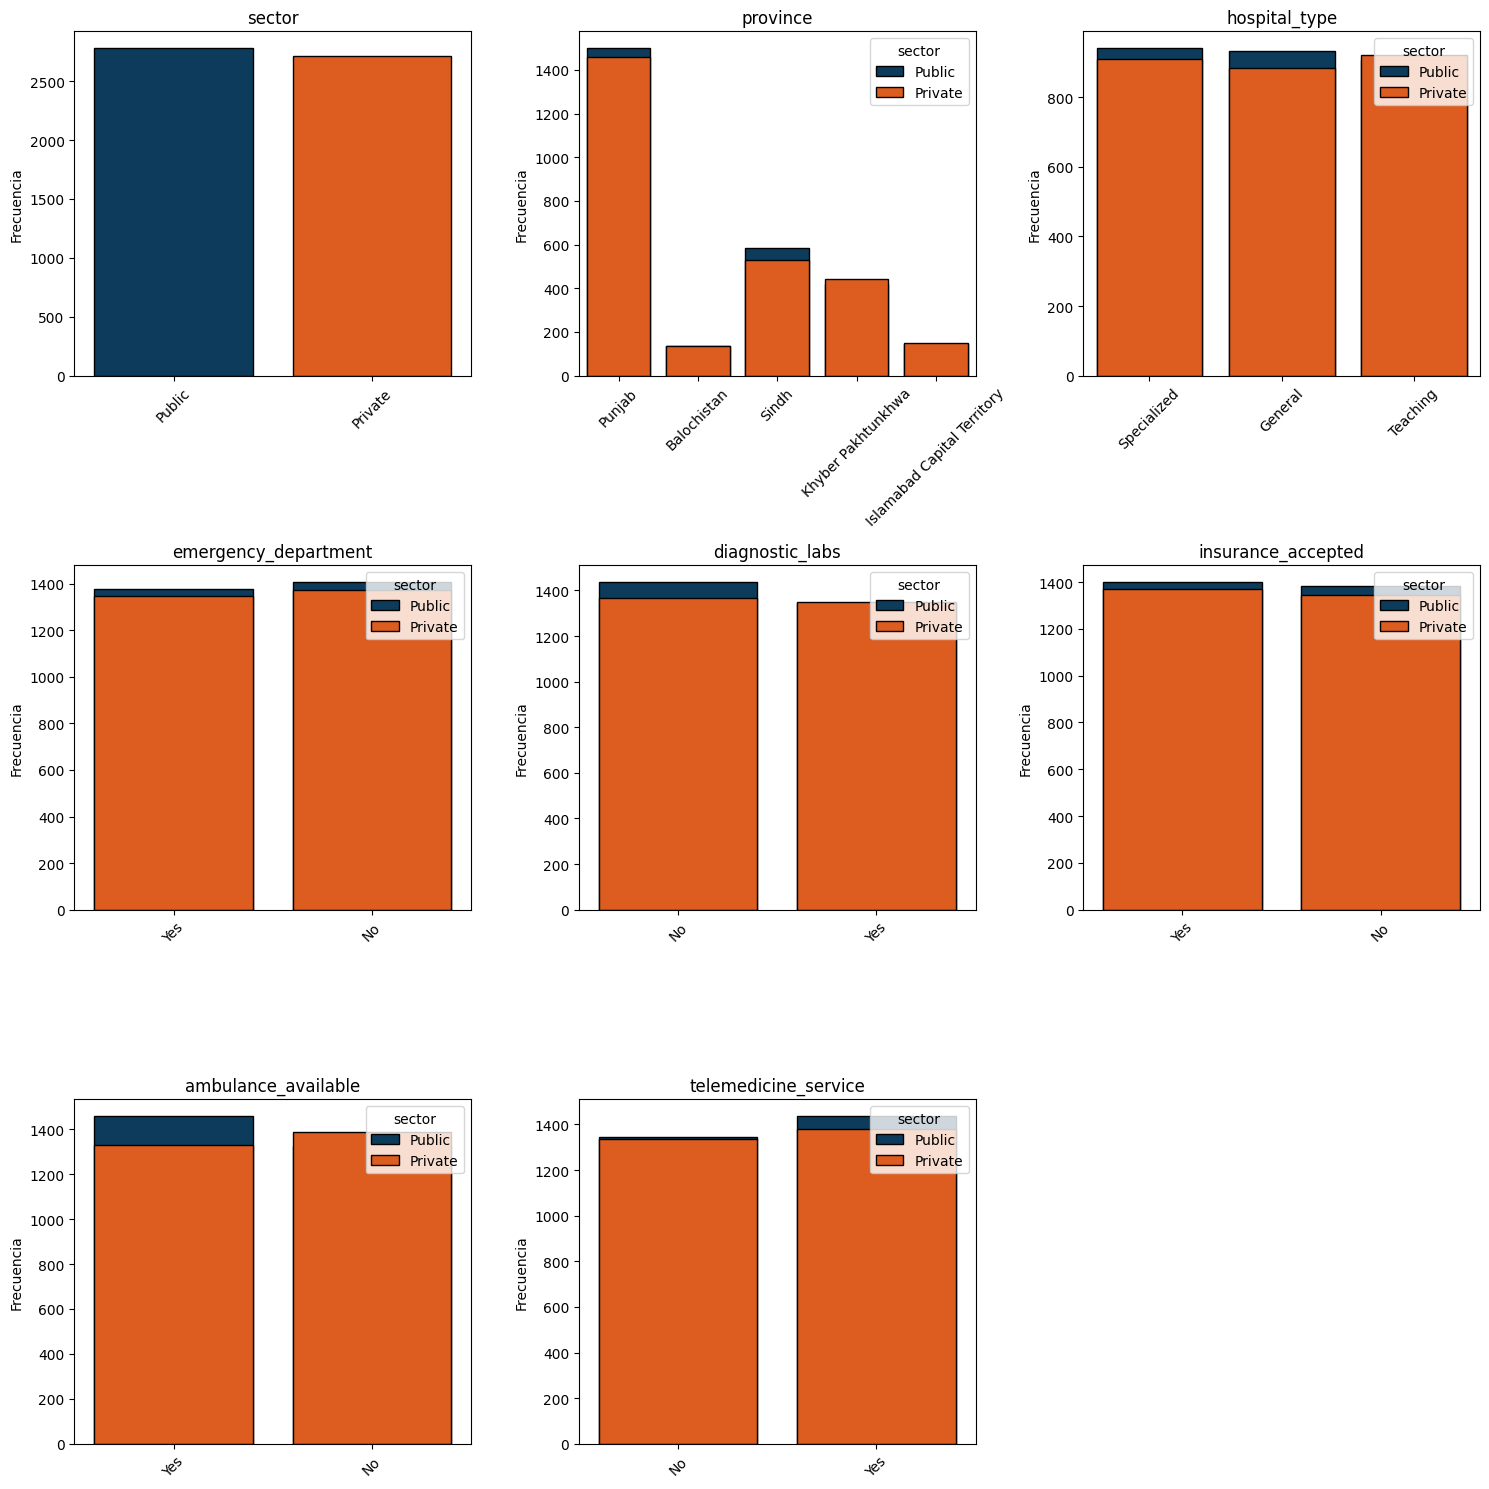

In [26]:
import math

# seleccionar variables categóricas
cat_cols = [
    col for col in df.select_dtypes(include=["object"]).columns
    if df[col].nunique() < 10  # filtro recomendable
]

n_cols = 3
n_rows = math.ceil(len(cat_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()  # simplifica indexado

for i, col in enumerate(cat_cols):
    ax = axes[i]

    sns.countplot(
        data=df,
        x=col,
        hue="sector",
        dodge=False,
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        ax=ax,
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")
    ax.tick_params(axis="x", rotation=45)

# eliminar ejes vacíos (si sobran)
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

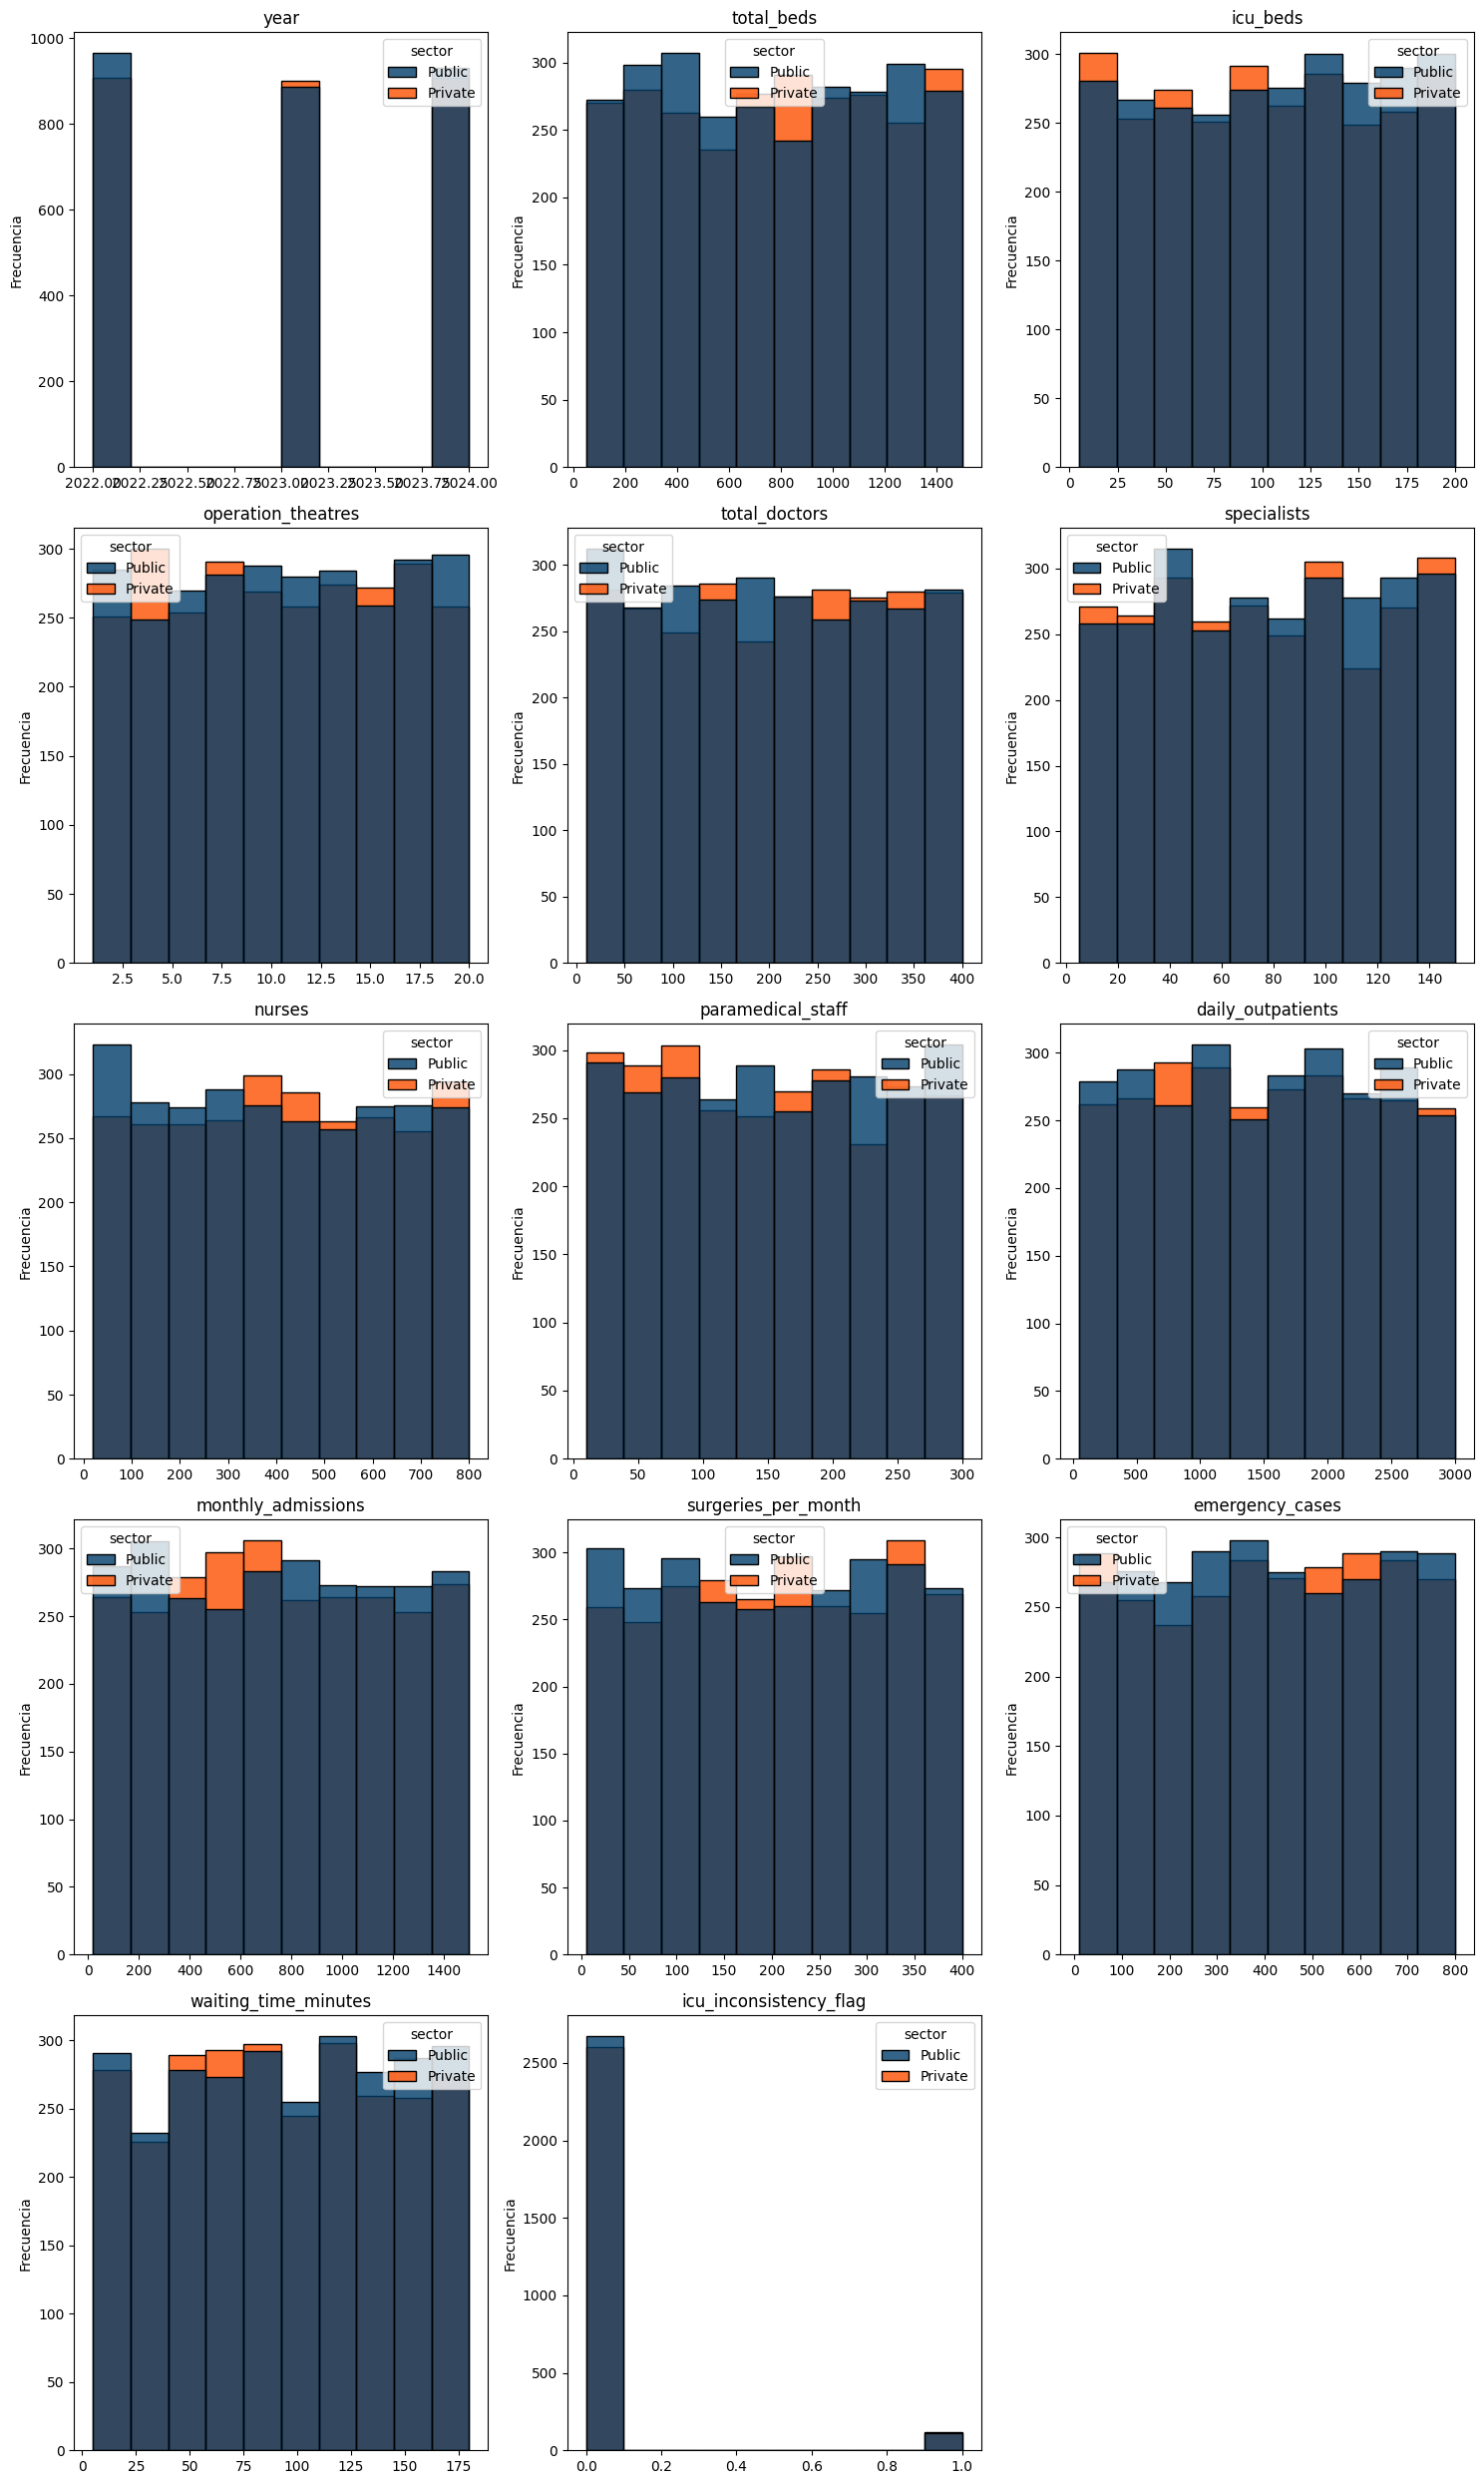

In [35]:
# seleccionar variables enteras
int_cols = df.select_dtypes(include=["int64", "int32"]).columns

n_cols = 3
n_rows = math.ceil(len(int_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(int_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue="sector",
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        alpha=0.8,
        ax=ax,
        bins=10
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

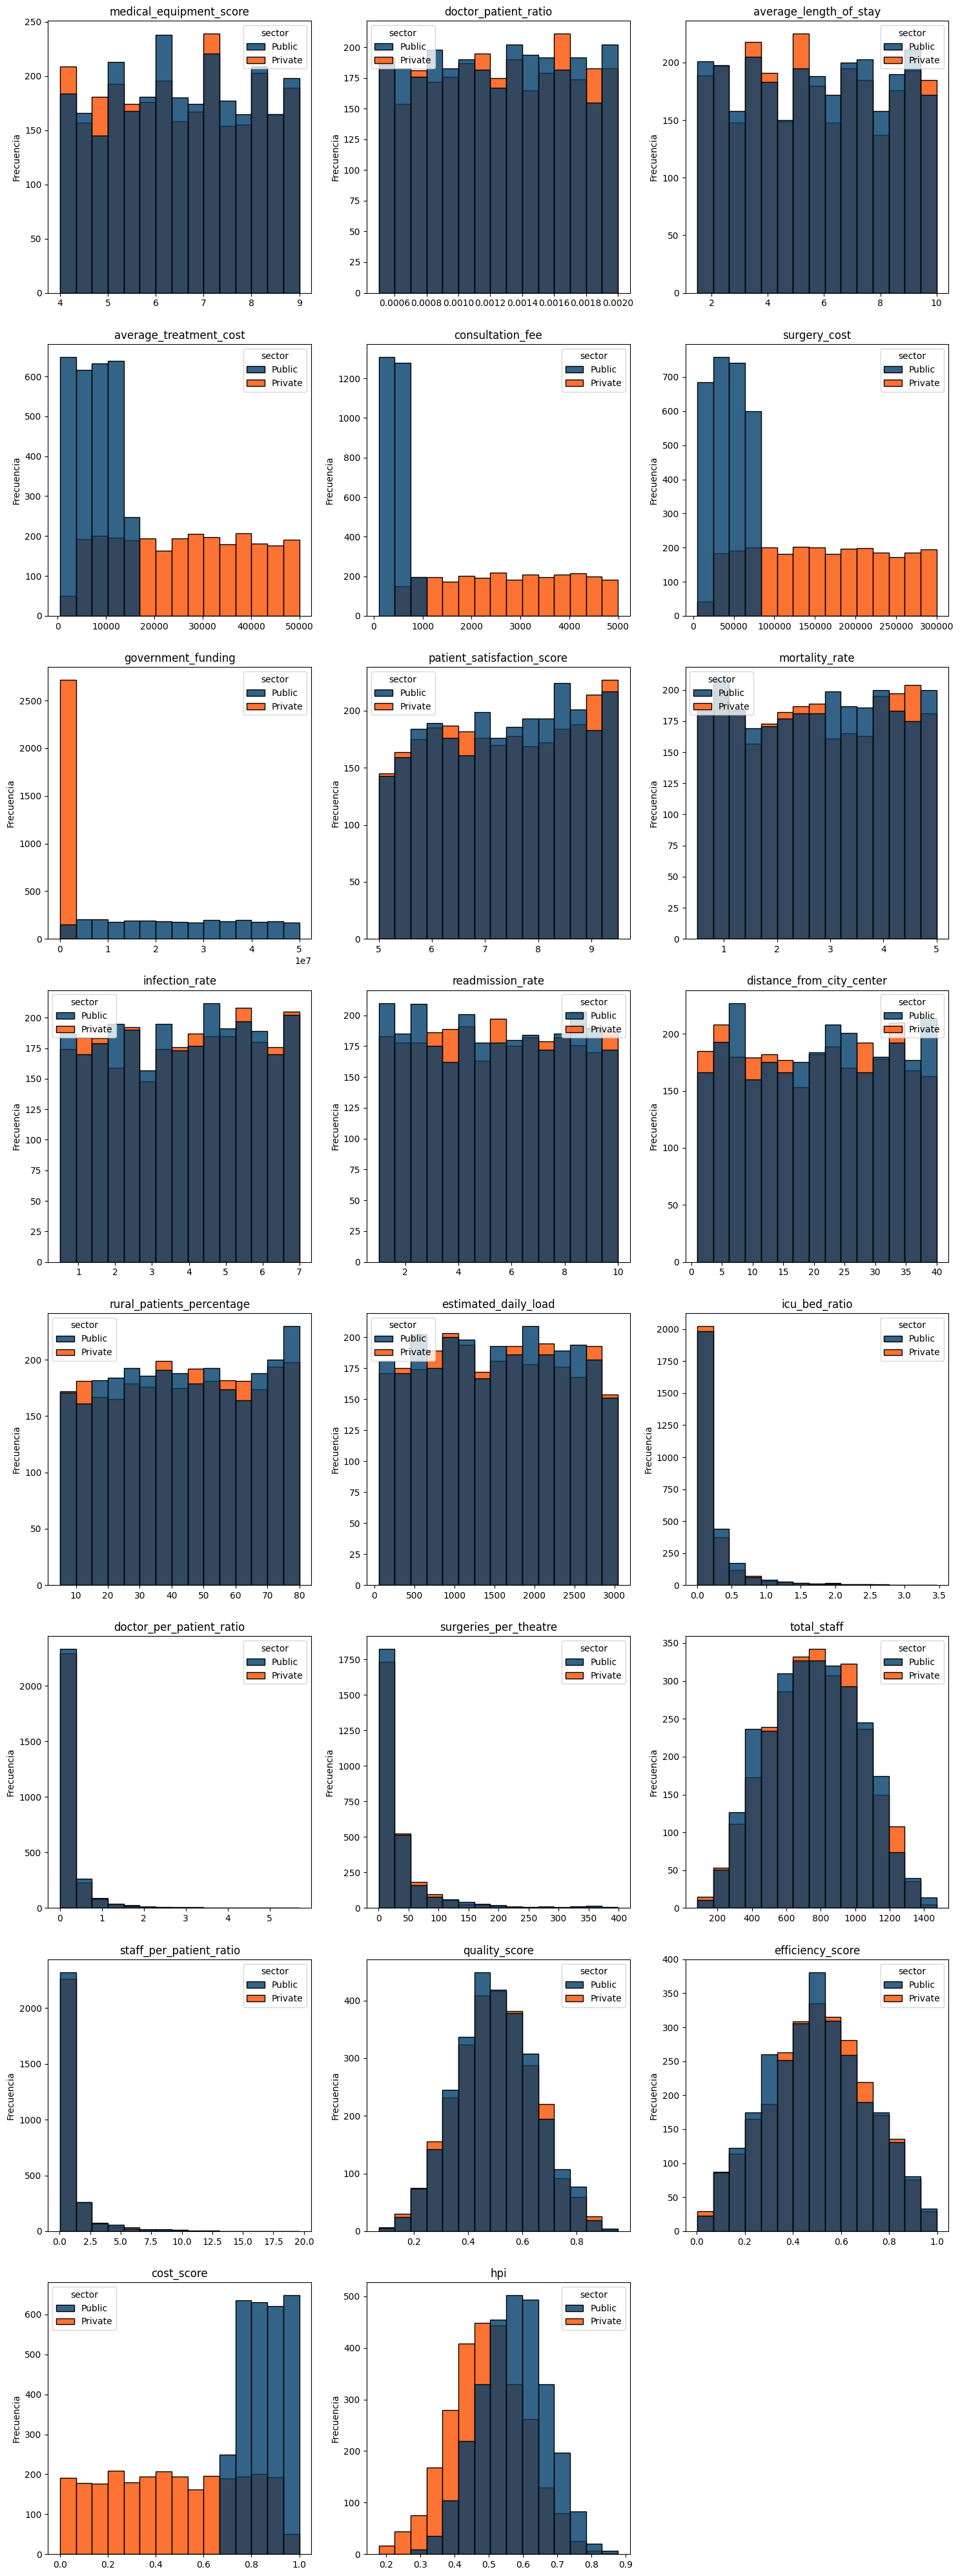

In [37]:
# seleccionar variables enteras
float_cols = df.select_dtypes(include=["float64", "float32"]).columns

n_cols = 3
n_rows = math.ceil(len(float_cols) / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
axes = axes.flatten()

for i, col in enumerate(float_cols):
    ax = axes[i]

    sns.histplot(
        data=df,
        x=col,
        hue="sector",
        palette={"Public": "#003d69", "Private": "#fd5000"},
        edgecolor="black",
        alpha=0.8,
        ax=ax,
        bins=15,
    )

    ax.set_title(col)
    ax.set_xlabel("")
    ax.set_ylabel("Frecuencia")

# eliminar ejes vacíos
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

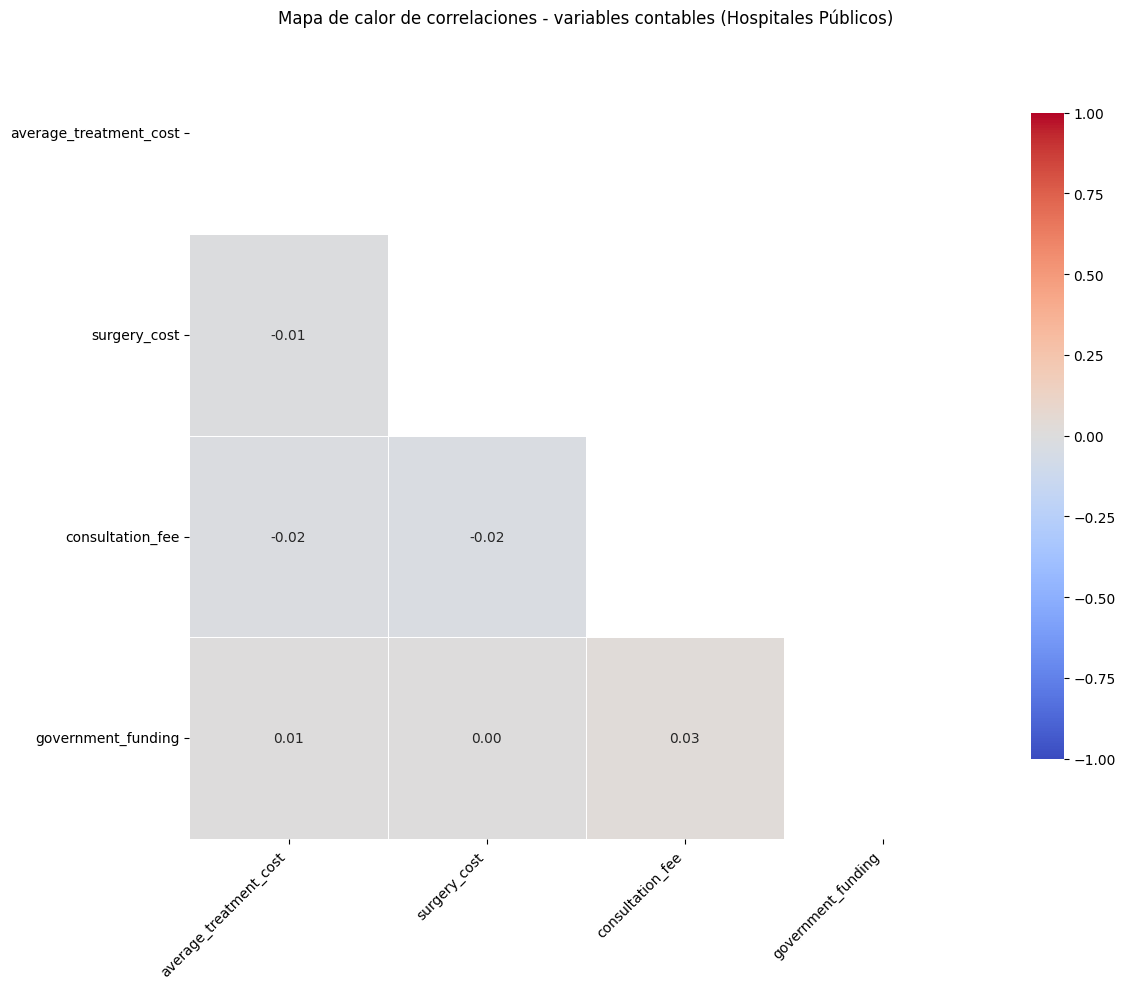

In [50]:
# Correlation heatmap - variables de contabilidad
# Hospitales públicos

cost_cols = [
    'average_treatment_cost',
    'surgery_cost',
    'consultation_fee',
    'government_funding'
]

corr_matrix = publicos[cost_cols].corr()

plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

sns.heatmap(
    corr_matrix,
    mask=mask,
    fmt=".2f",
    annot=True,
    cmap="coolwarm",
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    vmin=-1, vmax=1
)

plt.title("Mapa de calor de correlaciones - variables contables (Hospitales Públicos)")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()